# Bitcoin Market Sentiment Analysis

## Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using historical trading data from Hyperliquid. The analysis aims to identify trading patterns, evaluate profitability under different market conditions, and generate meaningful insights.

## Import Libraries

The following libraries are imported for data manipulation, visualization, and exploratory data analysis.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Load Datasets

This project uses two datasets:
- Historical Trading Data
- Bitcoin Fear & Greed Index

In [16]:
historical = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

## Dataset Overview

The datasets are explored to understand their structure, columns, and available information before analysis.

In [17]:
print("Historical.data")
display(historical.head())

print(historical.shape)
print(historical.info())

print("Fear Greed Data")
display(fear.head())
print(fear.head())
print(fear.shape)
print(fear.info())

historical.columns


Historical.data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [18]:
print(historical.describe())
print(fear.describe)

       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.732711e+08      -1.175712

## Data Cleaning

The datasets are checked for missing values and formatted appropriately to ensure accurate analysis.

In [19]:
print(historical.isnull().sum())
print(fear.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


## Data Preprocessing

The timestamp columns are converted into datetime format, and a common Date column is created for merging.

In [30]:
# Convert historical timestamp
historical['Timestamp IST'] = pd.to_datetime(historical['Timestamp IST'])

# Create Date column
historical['Date'] = historical['Timestamp IST'].dt.date

# Convert Fear & Greed date
fear['Date'] = pd.to_datetime(fear['date']).dt.date

# Check
print(historical[['Timestamp IST','Date']].head())

print(fear[['date','Date']].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date        Date
0  2018-02-01  2018-02-01
1  2018-02-02  2018-02-02
2  2018-02-03  2018-02-03
3  2018-02-04  2018-02-04
4  2018-02-05  2018-02-05


## Data Integration

The historical trading data is merged with the Bitcoin Fear & Greed Index using the Date column.

In [32]:
merged = pd.merge(
    historical,
    fear[['Date','classification']],
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [34]:
print("Missing Values\n")

print(merged.isnull().sum())

print("\nFear & Greed Distribution\n")

print(merged['classification'].value_counts())

Missing Values

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
classification      6
dtype: int64

Fear & Greed Distribution

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [35]:
merged.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211218
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,480,5
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,2025-02-25,Fear
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,6246,61837
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915009792,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,NaN,NaN
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,NaN,NaN
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,NaN,NaN
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,NaN,NaN
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,NaN,NaN
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,NaN,NaN


## Exploratory Data Analysis (EDA)

Different visualizations are created to analyze trader performance, market sentiment, and trading behavior.

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


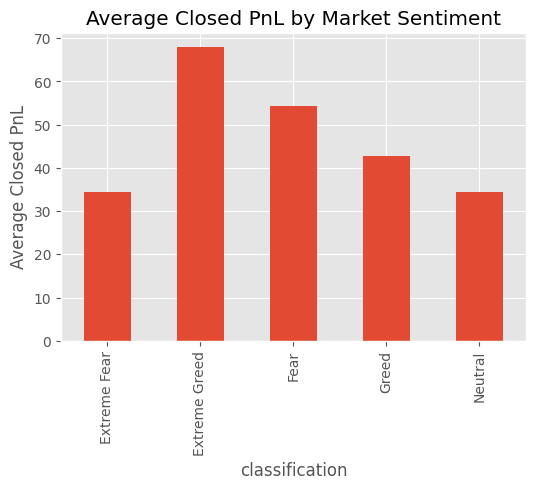

In [36]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

print(avg_pnl)

avg_pnl.plot(
    kind='bar',
    figsize=(6,4),
    title='Average Closed PnL by Market Sentiment'
)

plt.ylabel("Average Closed PnL")
plt.show()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


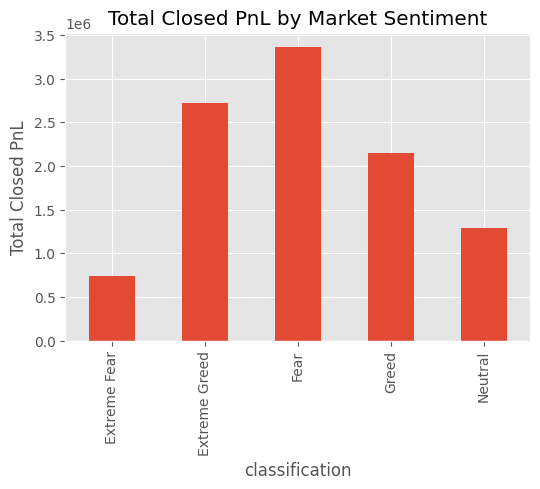

In [37]:
total_pnl = merged.groupby('classification')['Closed PnL'].sum()

print(total_pnl)

total_pnl.plot(
    kind='bar',
    figsize=(6,4),
    title='Total Closed PnL by Market Sentiment'
)

plt.ylabel("Total Closed PnL")
plt.show()

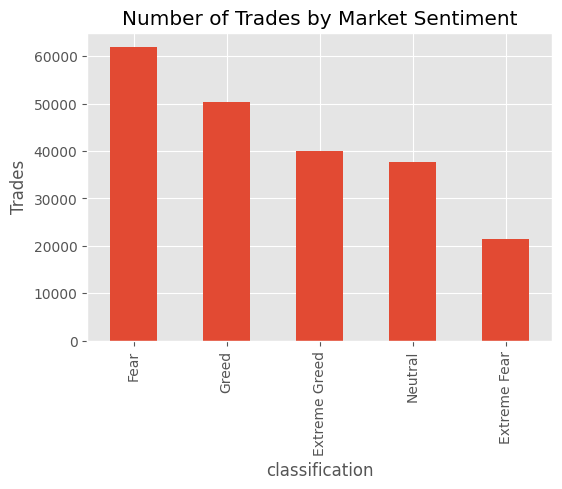

In [38]:
merged['classification'].value_counts().plot(
    kind='bar',
    figsize=(6,4),
    title="Number of Trades by Market Sentiment"
)

plt.ylabel("Trades")

plt.show()

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


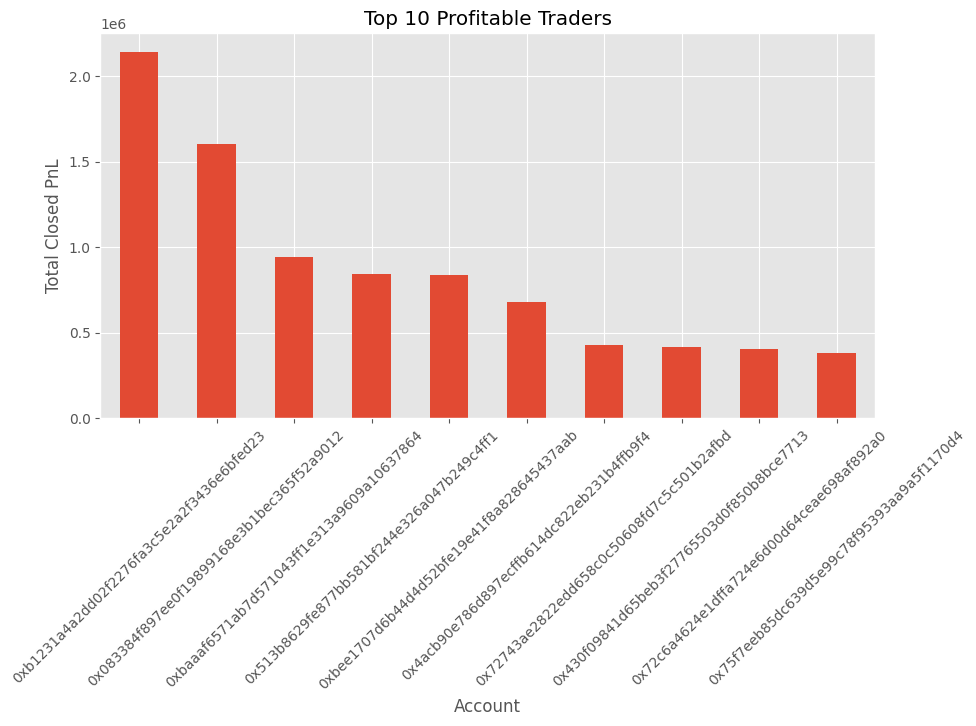

In [39]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

plt.figure(figsize=(10,5))
top_traders.plot(kind='bar')
plt.title("Top 10 Profitable Traders")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
Name: Closed PnL, dtype: float64


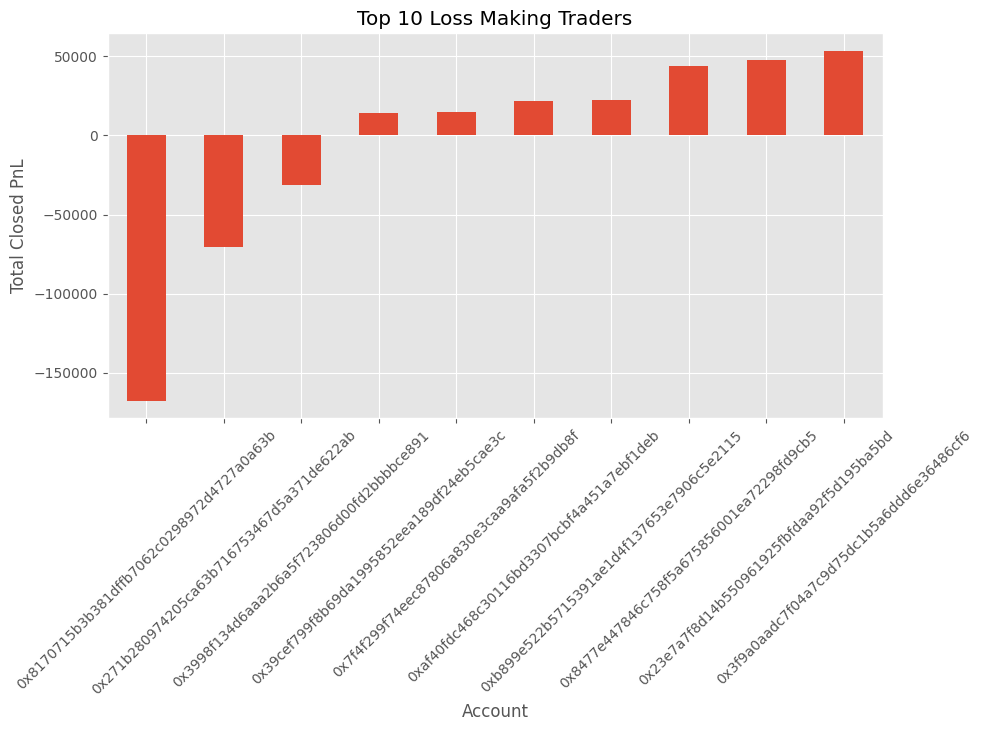

In [40]:
loss_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values()
    .head(10)
)

print(loss_traders)

plt.figure(figsize=(10,5))
loss_traders.plot(kind='bar')
plt.title("Top 10 Loss Making Traders")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


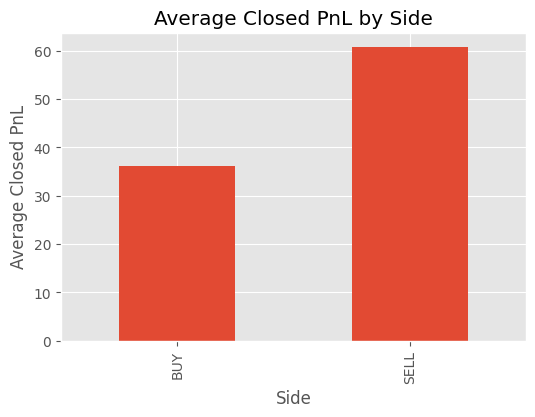

In [41]:
side_pnl = merged.groupby('Side')['Closed PnL'].mean()

print(side_pnl)

side_pnl.plot(kind='bar', figsize=(6,4))
plt.title("Average Closed PnL by Side")
plt.ylabel("Average Closed PnL")
plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


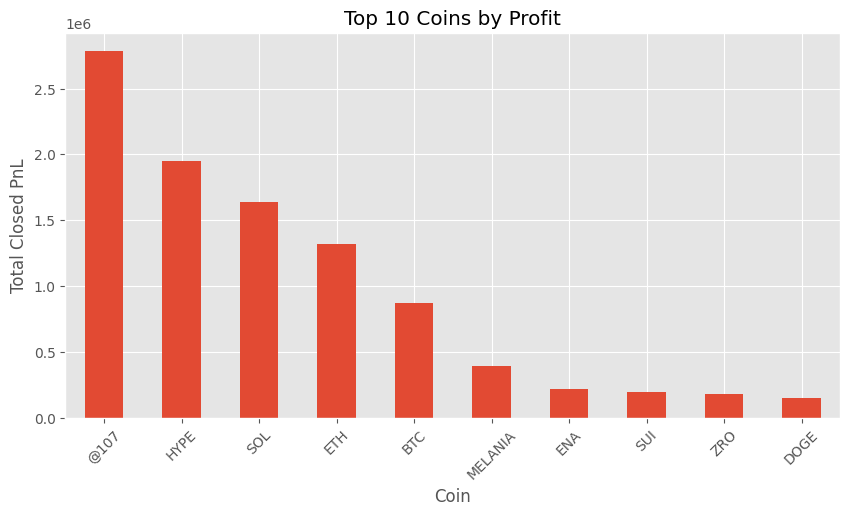

In [42]:
coin_profit = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(coin_profit)

coin_profit.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Coins by Profit")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Extreme Greed   10.498927  114.584643
Fear            63.927104   45.049641
Greed           25.002302   59.691091
Neutral         29.227429   39.456408


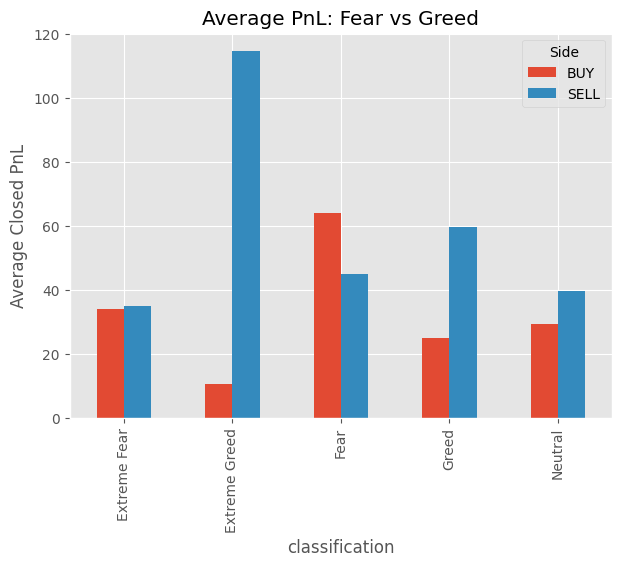

In [43]:
pivot = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

print(pivot)

pivot.plot(kind='bar', figsize=(7,5))
plt.title("Average PnL: Fear vs Greed")
plt.ylabel("Average Closed PnL")
plt.show()

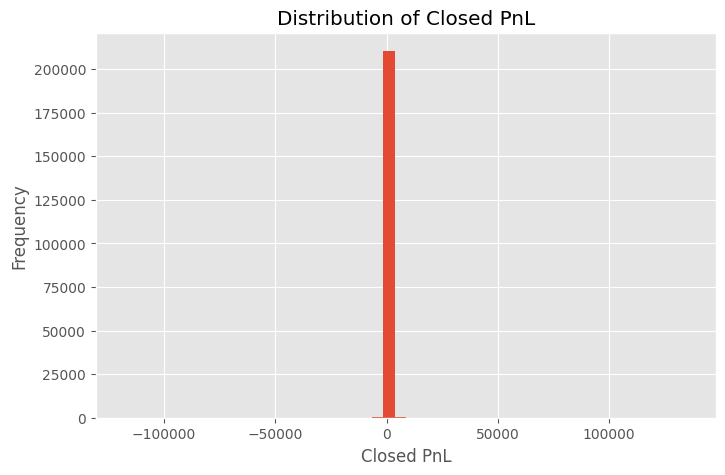

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    merged['Closed PnL'],
    bins=50
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

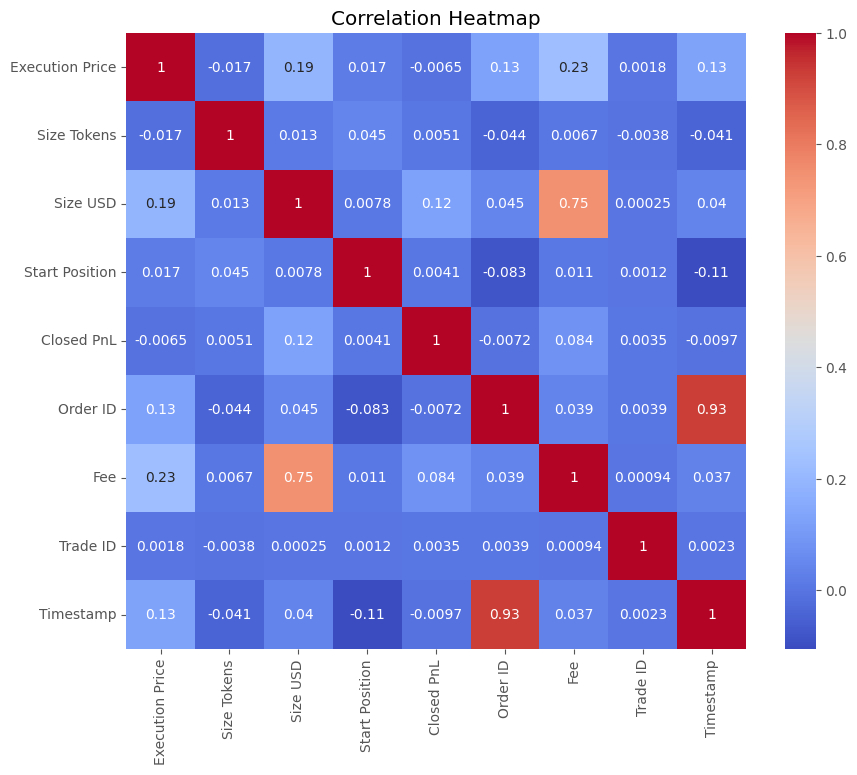

In [45]:
numeric = merged.select_dtypes(include=['number'])

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [48]:
merged.to_csv("merged_trading_sentiment.csv", index=False)

print("Dataset exported successfully.")

Dataset exported successfully.


# Key Findings

- Market sentiment influences trading behavior.
- Trader profitability changes across different market conditions.
- Buy and Sell trades show different performance patterns.
- Risk management and leverage play an important role in overall profitability.


# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader performance. The results indicate that market sentiment affects trading outcomes, but profitability also depends on trading strategy, leverage, and effective risk management.
